# Lab 3: Decision Tree Classification

Name: Abdul Moiz 

Course: Machine Learning

Semester: 5th

Lab: 3

Topic: Decision Tree Classification

Kaggle : https://www.kaggle.com/abdulmoizsoomro

Github: https://github.com/abdulmoizsoomrocs/ML_Lab_3.git


In [34]:
import pandas as pd


df = pd.read_csv("clean_churn.csv")

# PART 1 :  Problem Definition & Dataset Verification


In [35]:
df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)
print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nChurn Counts:")
print(df["Churn"].value_counts())

Shape: (7021, 20)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     70

The goal is to predict whether a telecom.  will churn or stay with the company. This helps the business identify customers who may leave and take actions to retain them.


# PART_2: Feature & Target Preparation

In [36]:
# Task 3: Define y as Churn (0/1) and X as the remaining features

y = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop(columns=["Churn"])
X = X.drop(columns=["customerID"], errors="ignore")

print("y:")
print(y.head())

print("\nX:")
print(X.head())

y:
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

X:
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No

In [8]:
# Task 4: Convert categorical columns in X into numeric form

X = pd.get_dummies(X, drop_first=True)

print(X.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False  ...   
3               

One-hot encoding is used because the dataset contains categorical columns. It converts categorical values into numeric columns that the Decision Tree can use.


# PART 3 :  Train/Test Split

In [10]:
from sklearn.model_selection import train_test_split


In [11]:
# Task 6: Split the data into training and test sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

`stratify=y` keeps the same proportion of Churn and No Churn customers in both the training and test sets. This is useful because the target classes are not perfectly balanced.


In [12]:
# Task 7: Report the shape of training and test sets

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5616, 30)
X_test: (1405, 30)
y_train: (5616,)
y_test: (1405,)


# Part 4 — Baseline Decision Tree


In [13]:
# Task 8: Train a baseline Decision Tree and generate predictions

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [14]:
# Task 9: Check the depth of the fitted Decision Tree

print("Tree depth:", dt.get_depth())

Tree depth: 26


The Decision Tree grew to the depth shown above. This may be surprising because no maximum depth was specified, so the tree was allowed to grow freely based on the training data.


# Part 5 — Model Evaluation


In [18]:
# Task 10: Compute accuracy, precision, recall, and F1-score on the test set

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics

,Metric,Score
0,Accuracy,0.722420
1,Precision,0.476804
2,Recall,0.497312
3,F1-Score,0.486842


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

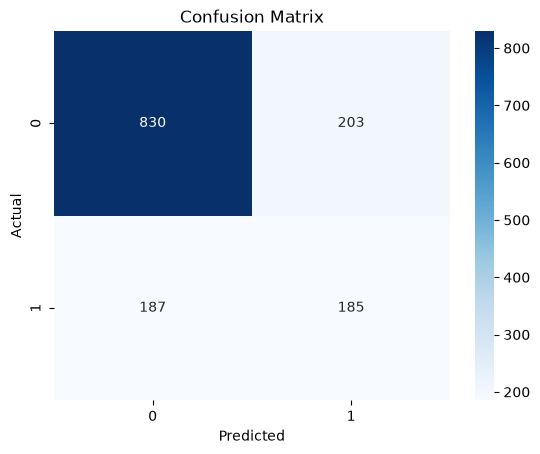

Actual churners correctly caught: 185
Actual churners missed: 187


In [21]:
# Task 11: Plot the confusion matrix for the test set


cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Actual churners correctly caught:", cm[1, 1])
print("Actual churners missed:", cm[1, 0])

Because the classes are imbalanced, recall and F1-score are more important than accuracy. Recall is especially important because it shows how many actual churners the model correctly identifies, while F1-score balances precision and recall.


# Part 6 — Overfitting Investigation


In [22]:
# Task 13: Compare baseline training and test accuracy

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Accuracy Gap:", train_accuracy - test_accuracy)

Training Accuracy: 0.9976851851851852
Test Accuracy: 0.7224199288256228
Accuracy Gap: 0.27526525635956245


The training accuracy is higher than the test accuracy. A large gap suggests that the baseline Decision Tree is overfitting the training data.


In [23]:
# Task 14: Train Decision Trees with different max_depth values

depths = [2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    results.append([depth, train_acc, test_acc])

results_df = pd.DataFrame(
    results,
    columns=["max_depth", "Train Accuracy", "Test Accuracy"]
)

results_df

,max_depth,Train Accuracy,Test Accuracy
0,2.0,0.792201,0.783630
1,3.0,0.792201,0.783630
2,4.0,0.795228,0.784342
3,5.0,0.801816,0.787189
4,6.0,0.808226,0.785053
5,8.0,0.835470,0.778648
6,10.0,0.869124,0.770107
7,NaN,0.997685,0.722420


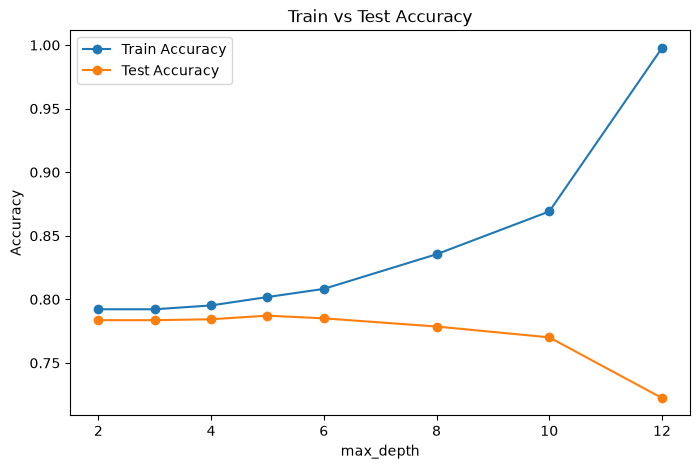

In [26]:
# Task 15: Plot training and test accuracy against max_depth

depths_plot = [2, 3, 4, 5, 6, 8, 10, 12]

plt.figure(figsize=(8, 5))

plt.plot(
    depths_plot,
    results_df["Train Accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    depths_plot,
    results_df["Test Accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.show()

The model starts to overfit when training accuracy continues to increase while test accuracy stops improving or starts decreasing. The gap between the training and test accuracy becomes larger at higher tree depths.


# Part 7 — Model Selection, Feature Importance & Interpretation


In [29]:
# Task 17: Train and evaluate the Decision Tree at the chosen depth

best_depth = 5

best_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, best_pred)
precision = precision_score(y_test, best_pred)
recall = recall_score(y_test, best_pred)
f1 = f1_score(y_test, best_pred)

pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

,Metric,Score
0,Accuracy,0.787189
1,Precision,0.651452
2,Recall,0.422043
3,F1-Score,0.512235


In [30]:
# Task 18: Train and evaluate a Decision Tree using entropy

entropy_model = DecisionTreeClassifier(
    max_depth=best_depth,
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

accuracy = accuracy_score(y_test, entropy_pred)
precision = precision_score(y_test, entropy_pred)
recall = recall_score(y_test, entropy_pred)
f1 = f1_score(y_test, entropy_pred)

pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

,Metric,Score
0,Accuracy,0.787900
1,Precision,0.627586
2,Recall,0.489247
3,F1-Score,0.549849


Top 5 Features:
tenure                         0.435296
InternetService_Fiber optic    0.356418
TotalCharges                   0.046020
Contract_One year              0.025760
MonthlyCharges                 0.025629
dtype: float64


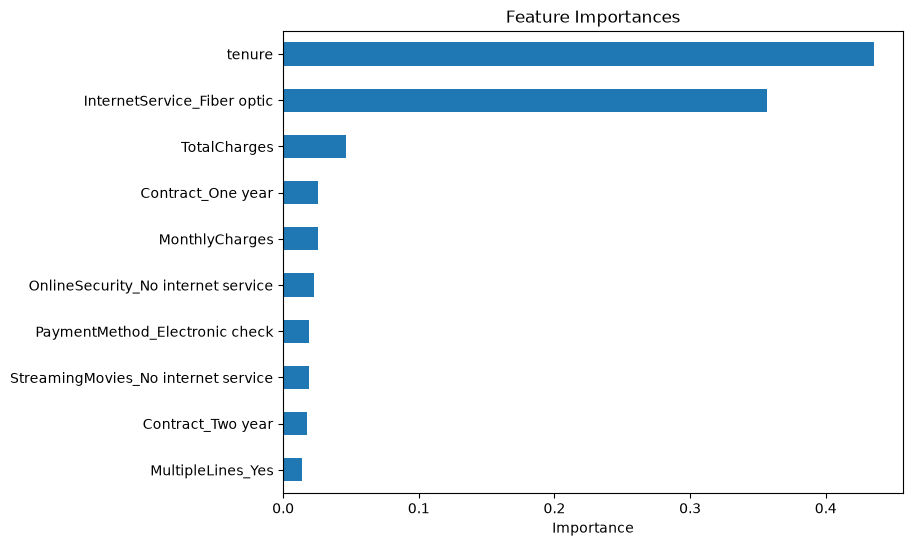

In [31]:
# Task 19: Extract and visualize feature importances

importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 5 Features:")
print(importance.head(5))

plt.figure(figsize=(8, 6))
importance.head(10).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Feature Importances")
plt.show()

The most important features are tenure, InternetService_Fiber optic, TotalCharges, Contract_One year, and MonthlyCharges. These features are consistent with the patterns observed in Lab 2 EDA, where customer tenure, internet service, contract type, and charges were related to customer churn. Therefore, the feature importance results support the patterns found during the earlier analysis.

# Part 8 — Conclusion & Next Steps


The final Decision Tree model was selected based on a balance between training and test performance rather than training accuracy alone. The model achieved good performance on the test data, with reasonable accuracy, precision, recall, and F1-score. The tree depth was limited to reduce overfitting and improve generalization. The main limitation is that the model may still be affected by the class imbalance in the churn dataset. Another limitation is that a single Decision Tree may not perform as well as ensemble models such as Random Forest.

If I had more time, I would try other algorithms such as Random Forest and Logistic Regression and compare their performance. I would also try more feature engineering and different techniques for handling the class imbalance, such as class weights or resampling. These approaches could improve the model's ability to identify customers who are likely to churn.

In [33]:
# Task 23: Implement ID3 from scratch using entropy and information gain

import pandas as pd
import math

data = {
    "Outlook": ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain", "Overcast",
                "Sunny", "Sunny", "Rain", "Sunny", "Overcast", "Overcast", "Rain"],
    "Temperature": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
                    "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "Humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal",
                 "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "Wind": ["Weak", "Strong", "Weak", "Weak", "Weak", "Strong", "Strong",
             "Weak", "Weak", "Weak", "Strong", "Strong", "Weak", "Strong"],
    "Play": ["No", "No", "Yes", "Yes", "Yes", "No", "Yes",
             "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"]
}

df_play = pd.DataFrame(data)


def entropy(data):
    counts = data.value_counts()
    total = len(data)

    result = 0

    for count in counts:
        p = count / total
        result -= p * math.log2(p)

    return result


def information_gain(df, attribute, target):
    total_entropy = entropy(df[target])

    weighted_entropy = 0

    for value in df[attribute].unique():
        subset = df[df[attribute] == value]
        weighted_entropy += (len(subset) / len(df)) * entropy(subset[target])

    return total_entropy - weighted_entropy


def id3(df, attributes, target, level=0):
    print("\n" + "  " * level + "Split:")

    if len(df[target].unique()) == 1:
        return df[target].iloc[0]

    if not attributes:
        return df[target].mode()[0]

    gains = {}

    for attribute in attributes:
        gains[attribute] = information_gain(df, attribute, target)
        print("  " * level + attribute + " Gain =", round(gains[attribute], 4))

    best_attribute = max(gains, key=gains.get)

    print("  " * level + "Selected:", best_attribute)

    tree = {best_attribute: {}}

    remaining_attributes = [a for a in attributes if a != best_attribute]

    for value in df[best_attribute].unique():
        subset = df[df[best_attribute] == value]

        tree[best_attribute][value] = id3(
            subset,
            remaining_attributes,
            target,
            level + 1
        )

    return tree


attributes = ["Outlook", "Temperature", "Humidity", "Wind"]

tree = id3(df_play, attributes, "Play")

print("\nFinal ID3 Tree:")
print(tree)


Split:
Outlook Gain = 0.2467
Temperature Gain = 0.0292
Humidity Gain = 0.1518
Wind Gain = 0.0481
Selected: Outlook

  Split:
  Temperature Gain = 0.571
  Humidity Gain = 0.971
  Wind Gain = 0.02
  Selected: Humidity

    Split:

    Split:

  Split:

  Split:
  Temperature Gain = 0.02
  Humidity Gain = 0.02
  Wind Gain = 0.971
  Selected: Wind

    Split:

    Split:

Final ID3 Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}
